# 대출 승인 예측 ML 모델

고객의 대출 승인 여부를 예측하는 이진 분류 모델을 구축합니다.

- **데이터**: `training_data.csv` (5,000건, 13개 변수)
- **모델**: Logistic Regression, Random Forest, XGBoost, LightGBM 비교
- **평가 지표**: F1 Score (불균형 데이터 대응)

## 1. 라이브러리 임포트 & 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')

# 한글 폰트 설정
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42
print('라이브러리 로드 완료')

라이브러리 로드 완료


## 2. 데이터 로딩 & EDA(Exploratory Data Analysis, 탐색적 데이터 분석)
  - 모델을 만들기 전에 데이터의 특성을 파악하는 과정  

In [2]:
df = pd.read_csv('training_data.csv')
print(f'데이터 크기: {df.shape}')
print(f'결측치:\n{df.isnull().sum().sum()}')
df.head()

데이터 크기: (5000, 13)
결측치:
0


,나이,연봉,재산,예금,자동차배기량,자녀수,신청금액,신청기간월,학력점수,결혼점수,회사규모점수,대출분류점수,승인여부
0,60,128558572,208296113,77931182,3500,2,140883551,12,8,5,2,5,0
1,50,140556173,324263513,127892,0,1,103604064,60,6,7,3,4,1
2,36,67565155,154716235,93332176,0,2,167194726,84,6,5,3,4,1
3,64,61346444,303101126,97313336,2000,4,149501970,84,6,7,4,4,1
4,29,117425380,261879248,172626183,3000,0,153148911,48,8,7,5,5,1


In [3]:
df.describe()

,나이,연봉,재산,예금,자동차배기량,자녀수,신청금액,신청기간월,학력점수,결혼점수,회사규모점수,대출분류점수,승인여부
count,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,43.575000,8.462080e+07,2.500917e+08,9.910208e+07,1389.920000,1.269600,1.032558e+08,54.412800,6.191200,5.867200,5.885600,5.901800,0.71180
std,12.554597,3.770817e+07,1.432924e+08,5.731650e+07,1084.495099,1.199668,5.622315e+07,33.879149,2.139242,1.189389,2.490412,1.256214,0.45297
min,22.000000,2.002425e+07,5.932200e+04,3.510300e+04,0.000000,0.000000,5.018187e+06,12.000000,2.000000,4.000000,2.000000,4.000000,0.00000
25%,33.000000,5.261519e+07,1.282034e+08,4.928371e+07,0.000000,0.000000,5.423831e+07,24.000000,6.000000,5.000000,4.000000,5.000000,0.00000
50%,44.000000,8.467797e+07,2.517114e+08,9.868092e+07,1600.000000,1.000000,1.044063e+08,48.000000,6.000000,7.000000,5.000000,6.000000,1.00000
75%,54.000000,1.172450e+08,3.717058e+08,1.475745e+08,2000.000000,2.000000,1.513397e+08,84.000000,8.000000,7.000000,7.000000,7.000000,1.00000
max,65.000000,1.499804e+08,4.999084e+08,1.999785e+08,3500.000000,4.000000,1.999627e+08,120.000000,10.000000,7.000000,10.000000,8.000000,1.00000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   나이      5000 non-null   int64
 1   연봉      5000 non-null   int64
 2   재산      5000 non-null   int64
 3   예금      5000 non-null   int64
 4   자동차배기량  5000 non-null   int64
 5   자녀수     5000 non-null   int64
 6   신청금액    5000 non-null   int64
 7   신청기간월   5000 non-null   int64
 8   학력점수    5000 non-null   int64
 9   결혼점수    5000 non-null   int64
 10  회사규모점수  5000 non-null   int64
 11  대출분류점수  5000 non-null   int64
 12  승인여부    5000 non-null   int64
dtypes: int64(13)
memory usage: 507.9 KB


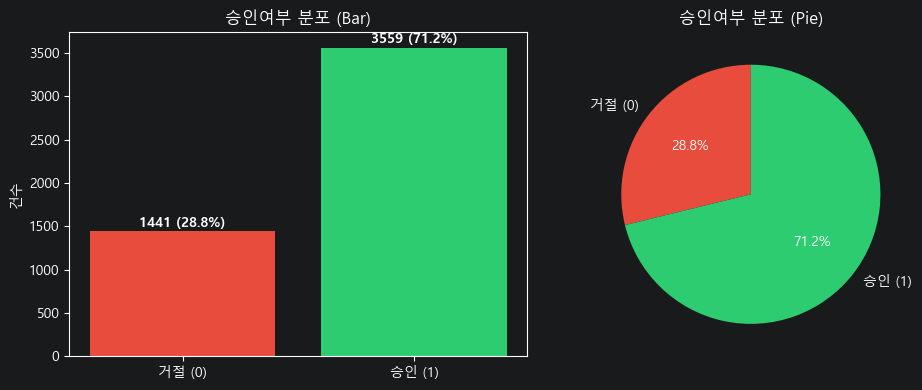

In [5]:
# 타겟 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

target_counts = df['승인여부'].value_counts().sort_index()
labels = ['거절 (0)', '승인 (1)']

axes[0].bar(labels, target_counts.values, color=['#e74c3c', '#2ecc71'])
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('승인여부 분포 (Bar)')
axes[0].set_ylabel('건수')

axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('승인여부 분포 (Pie)')

plt.tight_layout()
plt.show()

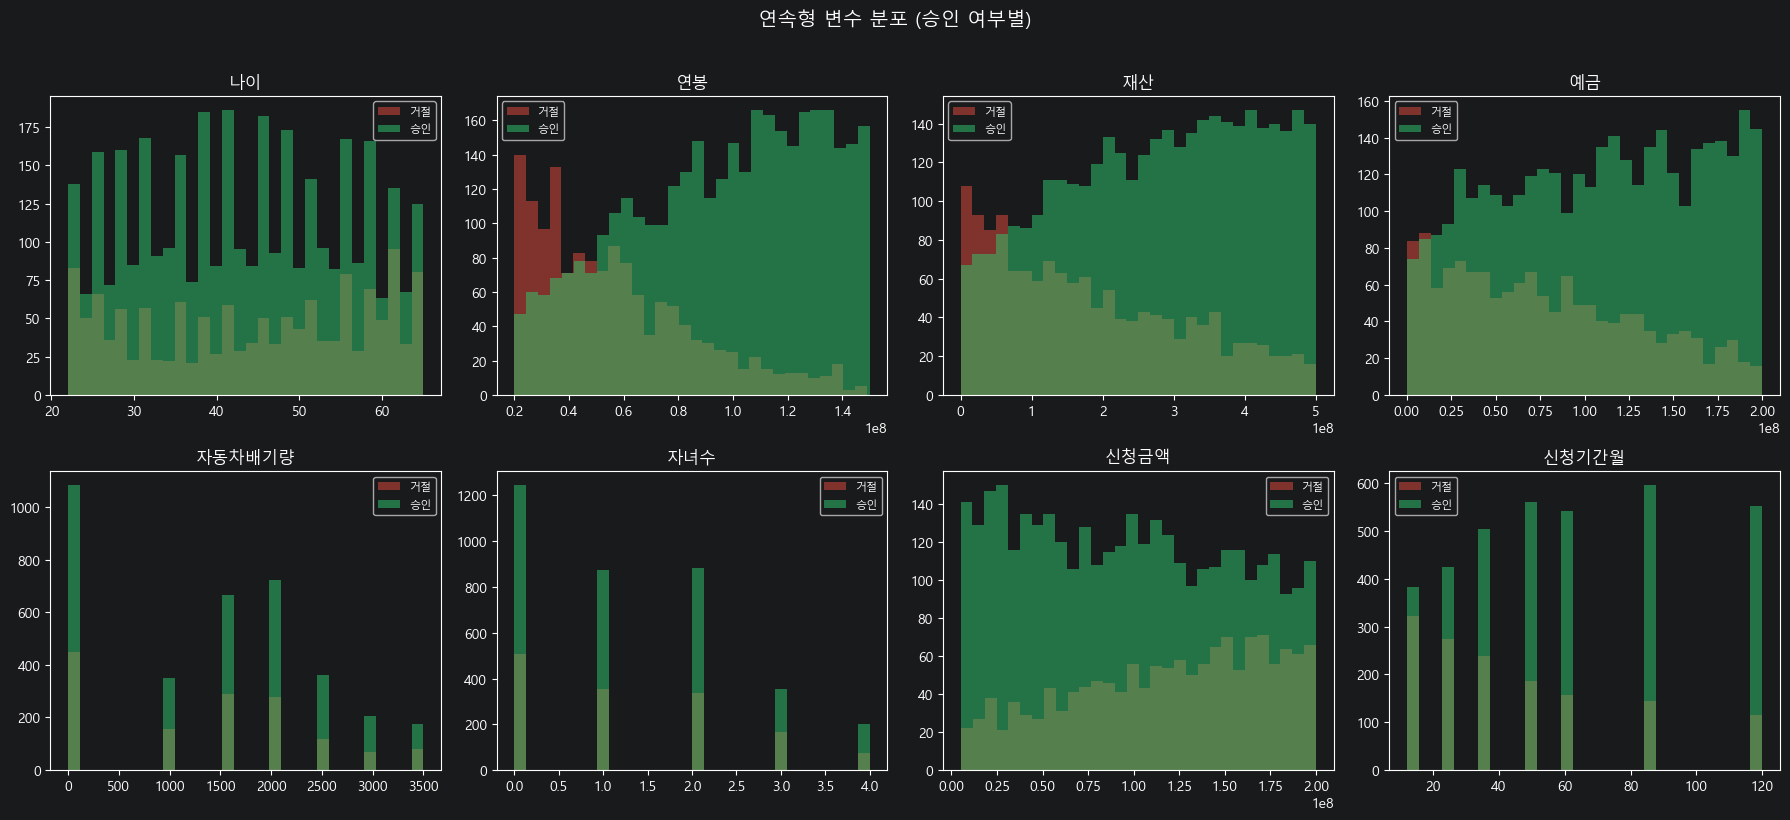

In [6]:
# 연속형 변수 히스토그램 (승인 여부별)
continuous_cols = ['나이', '연봉', '재산', '예금', '자동차배기량', '자녀수', '신청금액', '신청기간월']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for idx, col in enumerate(continuous_cols):
    ax = axes[idx // 4, idx % 4]
    for label, color in [(0, '#e74c3c'), (1, '#2ecc71')]:
        ax.hist(df[df['승인여부'] == label][col], bins=30, alpha=0.5,
                label=f'거절' if label == 0 else '승인', color=color)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('연속형 변수 분포 (승인 여부별)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

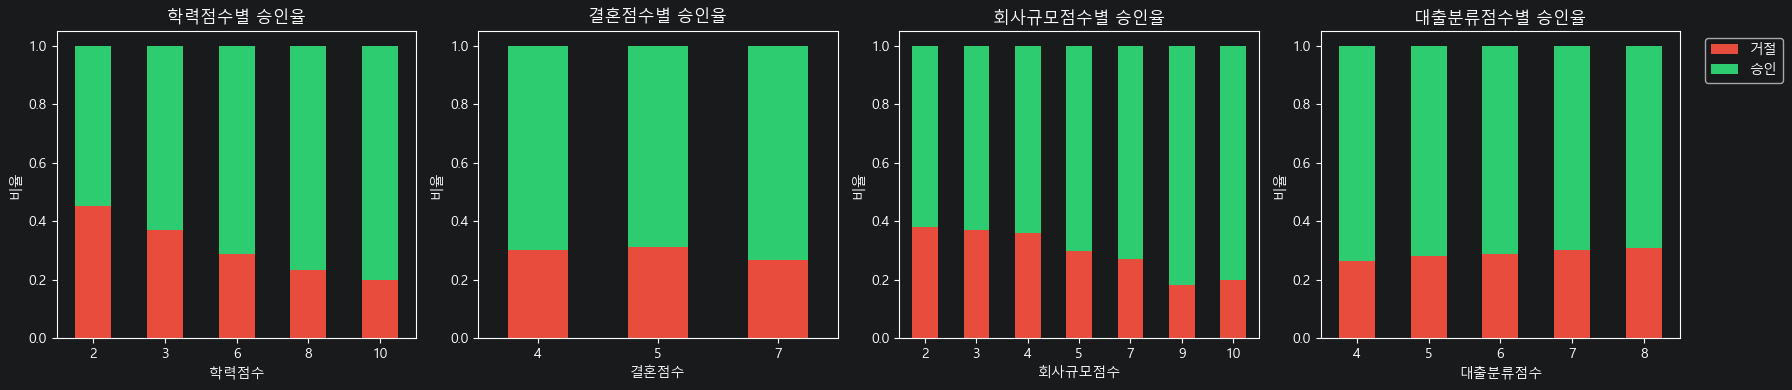

In [7]:
# 이산형 변수별 승인율 stacked bar
discrete_cols = ['학력점수', '결혼점수', '회사규모점수', '대출분류점수']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx, col in enumerate(discrete_cols):
    ct = pd.crosstab(df[col], df['승인여부'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[idx],
            color=['#e74c3c', '#2ecc71'], legend=False)
    axes[idx].set_title(f'{col}별 승인율')
    axes[idx].set_ylabel('비율')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)

axes[-1].legend(['거절', '승인'], bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

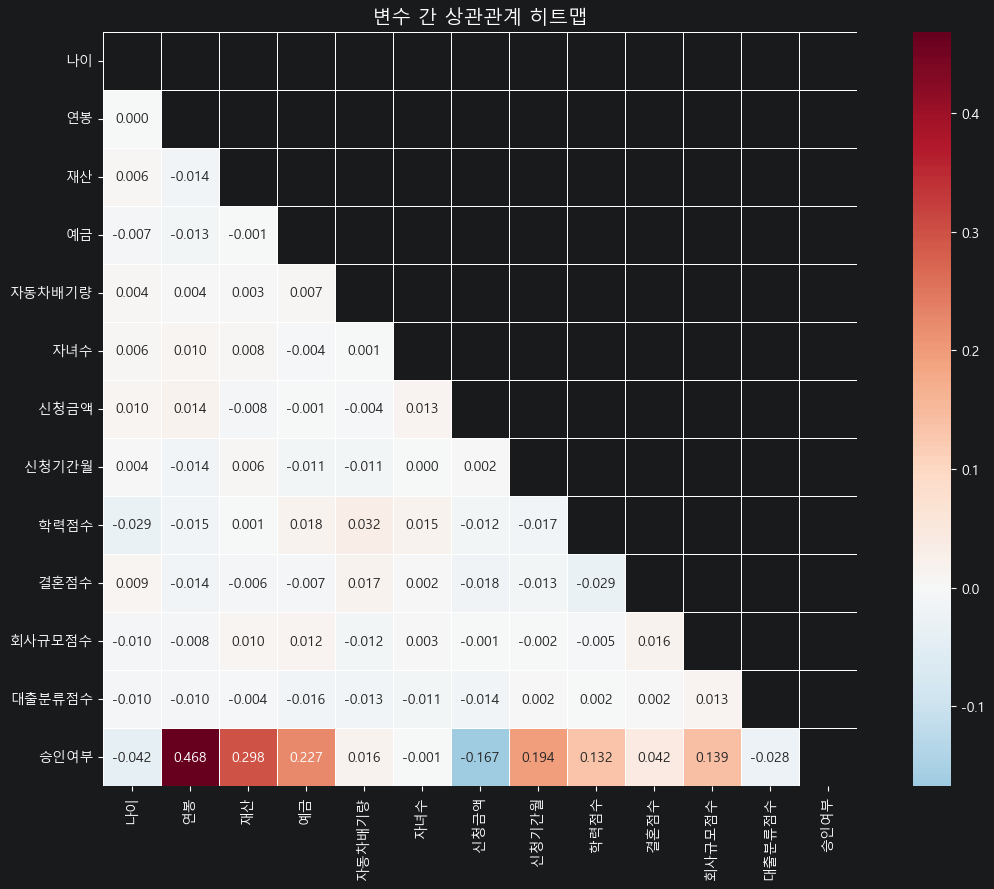

In [8]:
# 상관관계 히트맵
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('변수 간 상관관계 히트맵', fontsize=14)
plt.tight_layout()
plt.show()

## 3. 피처 엔지니어링 & 전처리

In [9]:
# 파생 변수 생성
df['신청금액_연봉비율'] = df['신청금액'] / (df['연봉'] + 1)        # DTI 유사
df['신청금액_재산비율'] = df['신청금액'] / (df['재산'] + 1)        # LTV 유사
df['총자산'] = df['연봉'] + df['재산'] + df['예금']               # 총 자산
df['자동차보유'] = (df['자동차배기량'] > 0).astype(int)            # 자동차 보유 여부
df['월상환추정'] = df['신청금액'] / (df['신청기간월'] + 1)         # 월 상환 추정액

print('파생 변수 생성 완료')
print(f'최종 피처 수: {df.shape[1] - 1}')
df[['신청금액_연봉비율', '신청금액_재산비율', '총자산', '자동차보유', '월상환추정']].describe()

파생 변수 생성 완료
최종 피처 수: 17


,신청금액_연봉비율,신청금액_재산비율,총자산,자동차보유,월상환추정
count,5000.000000,5000.000000,5.000000e+03,5000.000000,5.000000e+03
mean,1.606761,2.166590,4.338146e+08,0.694200,2.955763e+06
std,1.429189,40.966038,1.581651e+08,0.460792,3.034105e+06
min,0.039294,0.011514,4.637174e+07,0.000000,4.329325e+04
25%,0.651770,0.219368,3.141274e+08,0.000000,9.707313e+05
50%,1.218725,0.413573,4.371009e+08,1.000000,1.947141e+06
75%,2.030591,0.820349,5.572737e+08,1.000000,3.725084e+06
max,9.919390,2734.537532,8.277648e+08,1.000000,1.535999e+07


In [10]:
# Train/Test 분할
feature_cols = [c for c in df.columns if c != '승인여부']
X = df[feature_cols]
y = df['승인여부']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train 승인 비율: {y_train.mean():.3f}, Test 승인 비율: {y_test.mean():.3f}')

Train: (4000, 17), Test: (1000, 17)
Train 승인 비율: 0.712, Test 승인 비율: 0.712


In [11]:
# StandardScaler 적용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('스케일링 완료')

스케일링 완료


## 4. 모델 학습 & 교차 검증

In [12]:
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# --- 모델 설정 (여기서 어떤 AI 모델들을 쓸지 결정해요) ---
# 불균형 비율 계산 (대출 승인이 거절된 사람이 훨씬 많아서, 공평하게 배우도록 비율을 맞춰주는 거예요!)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count

models = {
    # --- [솔로 모델: 혼자서 판단해요] ---
    # 1. 로지스틱 회귀: 가장 기본적인 실력을 가진 솔로 가수 (기준점)
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
    # 2. 의사결정나무: 스무고개 하듯이 질문하며 찾아가는 솔로 가수 (설명이 쉬워요)
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE
    ),

    # --- [앙상블 모델: 여러 명이 팀을 짜서 판단해요 (아이돌 그룹)] ---
    # 3. 랜덤 포레스트: 여러 나무들이 투표해서 결정하는 안정적인 아이돌 그룹
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    # 4. XGBoost: 틀린 문제를 복습하며 실력을 키우는 똑똑한 1등 후보 그룹
    'XGBoost': XGBClassifier(
        scale_pos_weight=1/scale_pos, n_estimators=200,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
    # 5. LightGBM: 속도가 매우 빠르고 효율적인 퍼포먼스 그룹
    'LightGBM': LGBMClassifier(
        is_unbalance=True, n_estimators=200,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
    # 6. CatBoost: [최종 병기] 글자 데이터 처리에 강하고 성능이 뛰어난 신인 그룹
    'CatBoost': CatBoostClassifier(
        auto_class_weights='Balanced', iterations=200, verbose=0, random_state=RANDOM_STATE
    )
}

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}
for name, model in models.items():
    result = cross_validate(
        model, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1
    )
    cv_results[name] = {
        'Accuracy': result['test_accuracy'].mean(),
        'Precision': result['test_precision'].mean(),
        'Recall': result['test_recall'].mean(),
        'F1': result['test_f1'].mean(),
        'ROC-AUC': result['test_roc_auc'].mean(),
    }
    print(f'{name}: F1={cv_results[name]["F1"]:.4f}, AUC={cv_results[name]["ROC-AUC"]:.4f}')

cv_df = pd.DataFrame(cv_results).T.round(4)
cv_df

Logistic Regression: F1=0.9110, AUC=0.9540
Decision Tree: F1=0.8831, AUC=0.7954
Random Forest: F1=0.9183, AUC=0.9508
XGBoost: F1=0.9295, AUC=0.9615
LightGBM: F1=0.9288, AUC=0.9637
CatBoost: F1=0.9302, AUC=0.9668


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8785,0.9515,0.8739,0.9110,0.9540
Decision Tree,0.8332,0.8815,0.8848,0.8831,0.7954
Random Forest,0.8810,0.8979,0.9399,0.9183,0.9508
XGBoost,0.8980,0.9143,0.9456,0.9295,0.9615
LightGBM,0.8990,0.9319,0.9259,0.9288,0.9637
CatBoost,0.9028,0.9499,0.9115,0.9302,0.9668


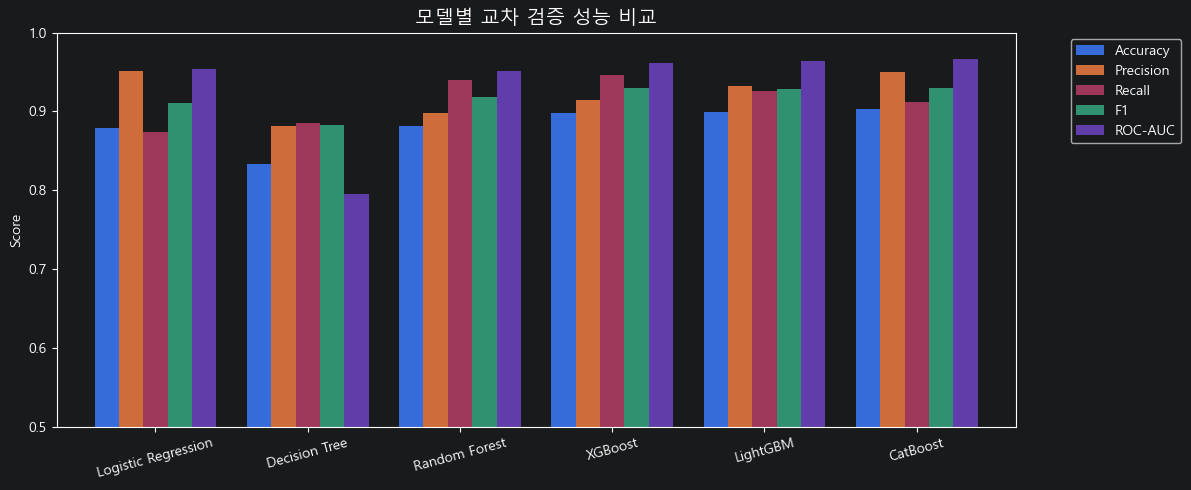

In [13]:
# 교차 검증 결과 바 차트
fig, ax = plt.subplots(figsize=(12, 5))
cv_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('모델별 교차 검증 성능 비교', fontsize=14)
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

## 5. 하이퍼파라미터 튜닝

상위 2개 모델에 대해 `RandomizedSearchCV`를 수행합니다.
<br> RandomizedSearchCV = 랜덤 탐색 교차 검증. 모델의 하이퍼파라미터(사람이 직접 설정해야 하는 값)를 자동으로 최적화하는 방법
   -  1. 지정한 범위에서 파라미터 조합을 랜덤으로 50개 뽑음 (n_iter=50)
 -  2. 각 조합마다 5-Fold 교차 검증으로 성능 측정
 -  3. F1 점수가 가장 높은 조합을 선택


In [14]:
# 1. 성능이 가장 좋았던 상위 2개 모델을 고릅니다.
top2 = cv_df['F1'].nlargest(2).index.tolist()
print(f'튜닝 대상 모델: {top2}')

# 2. 각 모델별로 '어떤 부분을 미세하게 조정할지' 메뉴판(탐색 공간)을 정의합니다.
param_spaces = {
    'Logistic Regression': {
        'C': uniform(0.01, 100),
        'penalty': ['l1', 'l2'],
        'solver': ['saga'],
    },
    'Decision Tree': { # [솔로 가수]를 위한 튜닝 메뉴
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
    },
    'Random Forest': {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30, 50],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', None],
    },
    'XGBoost': {
        'n_estimators': randint(100, 500),
        'max_depth': randint(3, 15),
        'learning_rate': uniform(0.01, 0.3),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 5),
    },
    'LightGBM': {
        'n_estimators': randint(100, 500),
        'max_depth': randint(3, 15),
        'learning_rate': uniform(0.01, 0.3),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'num_leaves': randint(20, 100),
        'min_child_samples': randint(5, 50),
    },
    'CatBoost': { # [아이돌 그룹 - CatBoost]를 위한 튜닝 메뉴
        'iterations': randint(100, 500),
        'depth': randint(4, 10),
        'learning_rate': uniform(0.01, 0.2),
        'l2_leaf_reg': randint(1, 10),
    },
}

tuned_models = {}
tuned_cv_results = {}

# 3. 위에서 고른 상위 2개 모델에 대해 실제로 최적의 설정을 찾습니다.
for name in top2:
    print(f'\n=== {name} 튜닝 중 (가장 좋은 설정을 찾는 중이에요) ===')
    base_model = models[name]
    
    # RandomizedSearchCV: 무작위로 시도해서 가장 좋은 성적을 내는 설정을 찾아요!
    search = RandomizedSearchCV(
        base_model, param_spaces[name],
        n_iter=20, # 너무 오래 걸릴 수 있으니 20번만 시도해봅니다.
        scoring='f1', cv=cv,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0
    )
    search.fit(X_train_scaled, y_train)
    
    tuned_models[name] = search.best_estimator_
    tuned_cv_results[name] = search.best_score_
    print(f'최고의 F1 점수: {search.best_score_:.4f}')
    print(f'최적의 설정값: {search.best_params_}')

# 4. 튜닝 전후 비교
comparison = pd.DataFrame({
    '튜닝 전 F1': {name: cv_results[name]['F1'] for name in top2},
    '튜닝 후 F1': tuned_cv_results,
})
comparison['개선폭'] = comparison['튜닝 후 F1'] - comparison['튜닝 전 F1']
comparison

튜닝 대상 모델: ['CatBoost', 'XGBoost']

=== CatBoost 튜닝 중 (가장 좋은 설정을 찾는 중이에요) ===
최고의 F1 점수: 0.9314
최적의 설정값: {'depth': 7, 'iterations': 393, 'l2_leaf_reg': 2, 'learning_rate': np.float64(0.04636499344142013)}

=== XGBoost 튜닝 중 (가장 좋은 설정을 찾는 중이에요) ===
최고의 F1 점수: 0.9345
최적의 설정값: {'colsample_bytree': np.float64(0.9085081386743783), 'gamma': np.float64(0.3702232586704518), 'learning_rate': np.float64(0.11753971856328177), 'max_depth': 11, 'min_child_weight': 7, 'n_estimators': 300, 'subsample': np.float64(0.8493192507310232)}


,튜닝 전 F1,튜닝 후 F1,개선폭
CatBoost,0.930225,0.931448,0.001222
XGBoost,0.929548,0.934506,0.004958


## 6. 최종 평가 (테스트 셋)

In [15]:
# --- [최종 실력 검증: 솔로 vs 앙상블, 누가 더 잘할까요?] ---
# 이제 실전에 투입된 솔로 모델과 앙상블 모델들의 진짜 실력을 확인해봅시다!
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

# 기본 모델(연습생)과 튜닝된 모델(데뷔 모델)을 모두 모아 평가합니다.
all_models = {}
for name, model in models.items():
    all_models[f'{name} (기본)'] = model
for name, model in tuned_models.items():
    all_models[f'{name} (튜닝)'] = model

test_results = {}
for name, model in all_models.items():
    # 1. 모델이 예측한 결과(y_pred)를 가져옵니다. (CatBoost 등 일부 모델을 위해 정수형으로 변환해줘요!)
    y_pred_raw = model.predict(X_test_scaled)
    y_pred = np.array(y_pred_raw).astype(int).flatten()
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # 2. 성능 지표를 계산합니다. (zero_division=0은 결과가 0인 경우에도 에러 없이 0으로 표시하라는 뜻이에요)
    test_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    }

# 결과를 표로 만들어 실력이 우수한 순서대로(F1 기준) 정렬해서 출력합니다.
test_df = pd.DataFrame(test_results).T.round(4)
test_df.sort_values('F1', ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost (튜닝),0.906,0.9221,0.9480,0.9349,0.9619
XGBoost (기본),0.897,0.9166,0.9410,0.9286,0.9556
LightGBM (기본),0.898,0.9395,0.9157,0.9275,0.9582
CatBoost (튜닝),0.898,0.9395,0.9157,0.9275,0.9603
CatBoost (기본),0.899,0.9499,0.9059,0.9274,0.9610
Random Forest (기본),0.882,0.9080,0.9284,0.9181,0.9476
Logistic Regression (기본),0.869,0.9462,0.8652,0.9039,0.9458
Decision Tree (기본),0.834,0.8922,0.8722,0.8821,0.8059


In [16]:
# 최적 모델 선택
best_name = test_df['F1'].idxmax()
best_model = all_models[best_name]
print(f'최적 모델: {best_name} (F1={test_df.loc[best_name, "F1"]:.4f})')

최적 모델: XGBoost (튜닝) (F1=0.9349)


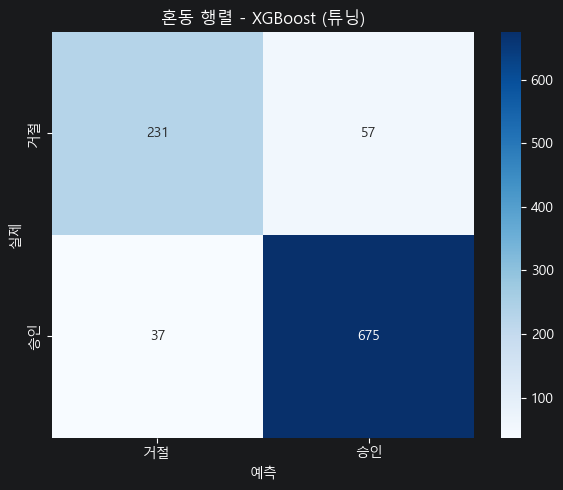

In [23]:
# 혼동 행렬 시각화
y_pred_best = best_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['거절', '승인'], yticklabels=['거절', '승인'])
ax.set_xlabel('예측')
ax.set_ylabel('실제')
ax.set_title(f'혼동 행렬 - {best_name}')
plt.tight_layout()
plt.show()

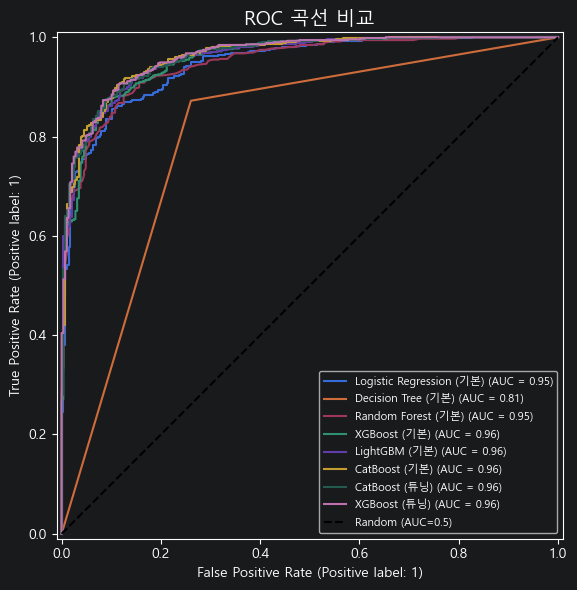

In [24]:
# ROC 곡선 시각화
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in all_models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
ax.set_title('ROC 곡선 비교', fontsize=14)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

In [25]:
# 최적 모델 분류 보고서
print(f'=== {best_name} 분류 보고서 ===')
print(classification_report(y_test, y_pred_best, target_names=['거절', '승인']))

=== XGBoost (튜닝) 분류 보고서 ===
              precision    recall  f1-score   support

          거절       0.86      0.80      0.83       288
          승인       0.92      0.95      0.93       712

    accuracy                           0.91      1000
   macro avg       0.89      0.88      0.88      1000
weighted avg       0.90      0.91      0.90      1000



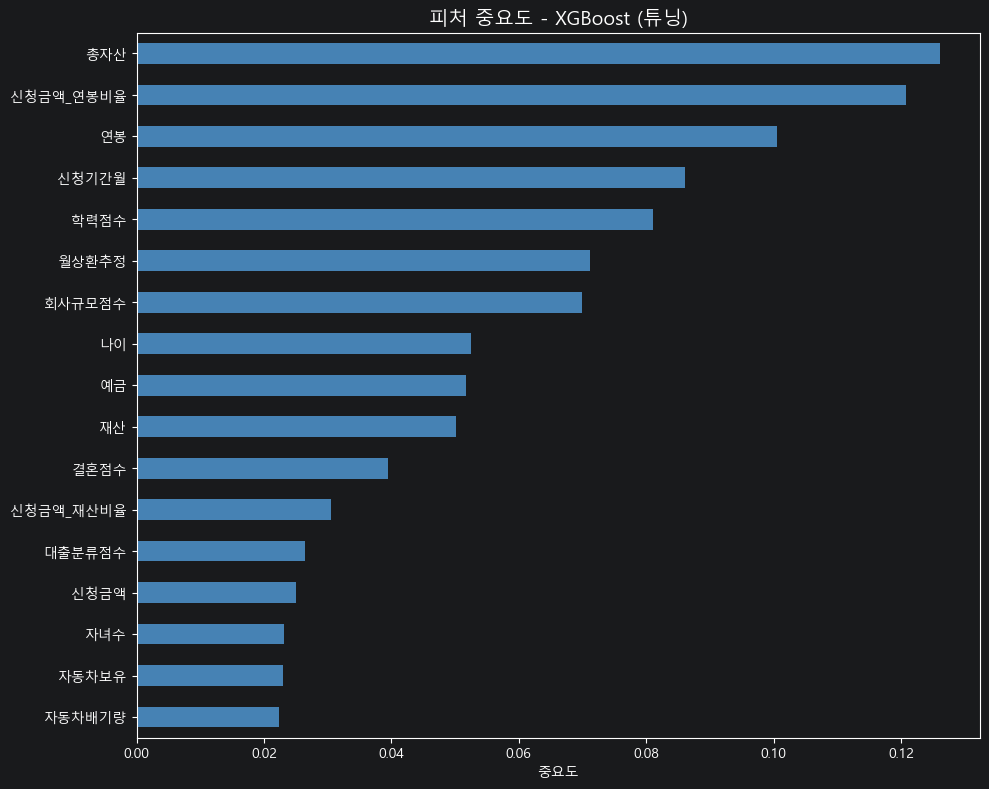

In [26]:
# 피처 중요도 시각화
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    feat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'피처 중요도 - {best_name}', fontsize=14)
    ax.set_xlabel('중요도')
    plt.tight_layout()
    plt.show()

## 7. 모델 저장 & 검증

In [27]:
# 모델, 스케일러, 메타데이터 저장
joblib.dump(best_model, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

metadata = {
    'model_name': best_name,
    'feature_cols': feature_cols,
    'test_f1': test_df.loc[best_name, 'F1'],
    'test_auc': test_df.loc[best_name, 'ROC-AUC'],
    'test_results': test_df.to_dict(),
}
joblib.dump(metadata, 'model_metadata.joblib')

print('저장 완료: best_model.joblib, scaler.joblib, model_metadata.joblib')

저장 완료: best_model.joblib, scaler.joblib, model_metadata.joblib


In [28]:
# 로드 후 예측 일치 검증
loaded_model = joblib.load('best_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')
loaded_meta = joblib.load('model_metadata.joblib')

X_test_reloaded = loaded_scaler.transform(X_test)
y_pred_reloaded = loaded_model.predict(X_test_reloaded)

match = np.array_equal(y_pred_best, y_pred_reloaded)
print(f'모델명: {loaded_meta["model_name"]}')
print(f'테스트 F1: {loaded_meta["test_f1"]:.4f}')
print(f'테스트 AUC: {loaded_meta["test_auc"]:.4f}')
print(f'예측 일치 검증: {"PASS" if match else "FAIL"}')

모델명: XGBoost (튜닝)
테스트 F1: 0.9349
테스트 AUC: 0.9619
예측 일치 검증: PASS
